# 🧠 Aula 04 - Parte 1: Preprocessamento Tabular, MLP Multicamadas e Treinamento Estável

Bem-vindo(a) à **Aula 04 (Parte 1)** do curso de Deep Learning com PyTorch da Faculdade Infnet!

Nesta aula, aplicaremos o pipeline moderno de Deep Learning em um problema tabular real da indústria: a **categorização automática da satisfação de clientes de E-commerce**.

---

### 🎯 Objetivos de Aprendizagem
1. **Preprocessamento Tabular Sem Vazamento de Dados (*Data Leakage*)**: Aprender a manipular variáveis numéricas e categóricas, tratar valores ausentes e construir um pipeline com `ColumnTransformer` ajustado estritamente no treino.
2. **Inspecionar Transformações Passo a Passo**: Visualizar a evolução dos dados desde o DataFrame bruto até os Tensores finais do PyTorch.
3. **Implementar a Arquitetura `EcommerceMLP`**: Estruturar redes neurais multicamadas modulares em PyTorch usando `nn.Module`.
4. **Analisar Inicialização de Pesos**: Avaliar o impacto das inicializações **Xavier/Glorot** e **He/Kaiming** em comparação com a inicialização padrão.
5. **Diagnosticar a Estabilidade do Treinamento**: Monitorar as **Normas de Gradientes** ($\|\nabla_{\theta} L\|_2$) ao longo das épocas para prevenir *Vanishing* ou *Exploding Gradients*.
6. **Comparar Normalização e Regularização**: Analisar o impacto de `BatchNorm1d`, `LayerNorm` e `Dropout` no desempenho de generalização.
7. **Avaliação Final no Teste**: Avaliar o melhor modelo no conjunto de teste com Matriz de Confusão e relatório completo.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Configuração de sementes para reprodutibilidade estrita
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Usando dispositivo: {device}")

🚀 Usando dispositivo: cpu


## 1. Carregamento e Inspeção Inicial do Dataset

Trabalharemos com o dataset **E-commerce Customer Behavior**, que registra o perfil demográfico, hábitos de compra e nível de satisfação dos clientes.

Vamos carregar o arquivo CSV e observar suas dimensões e os primeiros registros.

In [2]:
# Carregar dataset bruto
df_raw = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

print(f"📊 Dimensão original do dataset: {df_raw.shape} (linhas, colunas)\n")
print("🔍 Primeiras 5 linhas do DataFrame:")
display(df_raw.head())

print("\nℹ️ Informações sobre tipos de dados:")
df_raw.info()

📊 Dimensão original do dataset: (350, 11) (linhas, colunas)

🔍 Primeiras 5 linhas do DataFrame:


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied



ℹ️ Informações sobre tipos de dados:
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


## 2. Inspeção de Valores Ausentes e Limpeza do Alvo

Em problemas de aprendizado supervisionado, amostras que não possuem o rótulo alvo (*target*) não podem ser utilizadas no treinamento.

Vamos verificar os valores nulos por coluna e remover registros sem a informação de `Satisfaction Level`.

In [3]:
# Verificar nulos por coluna
print("❓ Quantidade de valores ausentes por coluna:")
print(df_raw.isnull().sum())

# Remover linhas onde o rótulo alvo (Satisfaction Level) é ausente
df = df_raw.dropna(subset=['Satisfaction Level']).copy()

print(f"\n🧹 Dimensão após remover alvos ausentes: {df.shape}")
print("\n📈 Distribuição das classes na variável alvo (Satisfaction Level):")
print(df['Satisfaction Level'].value_counts())

❓ Quantidade de valores ausentes por coluna:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

🧹 Dimensão após remover alvos ausentes: (348, 11)

📈 Distribuição das classes na variável alvo (Satisfaction Level):
Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Name: count, dtype: int64


## 3. Separação de Atributos (X) e Rótulos (y) e Codificação do Target

1. **Atributos ($X$)**: Removeremos `Customer ID` (pois é apenas um identificador sem poder preditivo) e a coluna alvo `Satisfaction Level`.
2. **Rótulo ($y$)**: Mapearemos o texto (`Unsatisfied`, `Neutral`, `Satisfied`) em inteiros ($0, 1, 2$) com o `LabelEncoder`.

In [4]:
# Separar atributos preditivos (X) e variável alvo (y)
X_raw = df.drop(columns=['Customer ID', 'Satisfaction Level'])
y_raw_labels = df['Satisfaction Level'].values

# Codificação da variável alvo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw_labels)

# Exibir o mapeamento das classes
class_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print(f"🏷️ Mapeamento de Classes: {class_mapping}")

print("\n👀 Amostra dos primeiros 10 rótulos codificados:")
for label_text, label_num in zip(y_raw_labels[:10], y_encoded[:10]):
    print(f"   • '{label_text}' ➔ {label_num}")

🏷️ Mapeamento de Classes: {'Neutral': 0, 'Satisfied': 1, 'Unsatisfied': 2}

👀 Amostra dos primeiros 10 rótulos codificados:
   • 'Satisfied' ➔ 1
   • 'Neutral' ➔ 0
   • 'Unsatisfied' ➔ 2
   • 'Satisfied' ➔ 1
   • 'Unsatisfied' ➔ 2
   • 'Neutral' ➔ 0
   • 'Satisfied' ➔ 1
   • 'Neutral' ➔ 0
   • 'Unsatisfied' ➔ 2
   • 'Satisfied' ➔ 1


## 4. Divisão Estratificada: Treino (70%), Validação (15%) e Teste (15%)

Dividiremos os dados garantindo que a proporção de cada classe seja mantida idêntica nos 3 conjuntos (`stratify=y_encoded`).

- **Treino (70%)**: Para o modelo aprender os parâmetros (pesos e viés).
- **Validação (15%)**: Para ajustar hiperparâmetros, comparar inicializações e salvar o melhor checkpoint.
- **Teste (15%)**: Reservado exclusivamente para a avaliação final cega.

In [5]:
# 1º Passo: Separar Treino (70%) e Conjunto Temporário (30%)
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_raw, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# 2º Passo: Dividir o Temporário igualmente em Validação (15%) e Teste (15%)
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"📊 Divisão dos dados realizada com sucesso:")
print(f"   • Conjunto de Treino:    {X_train_df.shape[0]} amostras ({X_train_df.shape[0]/len(df)*100:.1f}%)")
print(f"   • Conjunto de Validação: {X_val_df.shape[0]} amostras ({X_val_df.shape[0]/len(df)*100:.1f}%)")
print(f"   • Conjunto de Teste:     {X_test_df.shape[0]} amostras ({X_test_df.shape[0]/len(df)*100:.1f}%)")

# Verificar a proporção das classes no treino para confirmar a estratificação
print("\n⚖️ Proporção de classes no Treino:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   • Classe {u} ({label_encoder.classes_[u]}): {c} amostras ({c/len(y_train)*100:.1f}%)")

📊 Divisão dos dados realizada com sucesso:
   • Conjunto de Treino:    243 amostras (69.8%)
   • Conjunto de Validação: 52 amostras (14.9%)
   • Conjunto de Teste:     53 amostras (15.2%)

⚖️ Proporção de classes no Treino:
   • Classe 0 (Neutral): 75 amostras (30.9%)
   • Classe 1 (Satisfied): 87 amostras (35.8%)
   • Classe 2 (Unsatisfied): 81 amostras (33.3%)


## 5. Pré-Processamento Sem Vazamento de Dados (*Data Leakage*)

> **⚠️ Conceito Fundamental**:
> Todas as transformações e estatísticas (média, desvio padrão para `StandardScaler` e categorias para `OneHotEncoder`) devem ser aprendidas **exclusivamente no conjunto de Treino** (`fit_transform`).
> 
> Em seguida, aplicamos essa mesma transformação nos conjuntos de Validação e Teste (`transform`).

Identificaremos as colunas por tipo e construiremos o `ColumnTransformer`.

In [6]:
# Definir listas de colunas numéricas e categóricas
num_cols = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']
cat_cols = ['Gender', 'City', 'Membership Type', 'Discount Applied']

print("🔍 Visualizando dados brutos de Treino (Antes da Transformação):")
print("\n--- Colunas Numéricas ---")
display(X_train_df[num_cols].head(3))

print("\n--- Colunas Categóricas ---")
display(X_train_df[cat_cols].head(3))

🔍 Visualizando dados brutos de Treino (Antes da Transformação):

--- Colunas Numéricas ---


,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
161,36,460.5,8,3.1,19
139,34,790.2,11,4.0,15
278,30,1450.5,19,4.6,12



--- Colunas Categóricas ---


,Gender,City,Membership Type,Discount Applied
161,Female,Houston,Bronze,False
139,Male,Los Angeles,Silver,False
278,Male,San Francisco,Gold,False


In [7]:
# Construir o precessador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

# 1. Fit + Transform EXCLUSIVAMENTE no Treino
X_train = preprocessor.fit_transform(X_train_df)

# 2. Apenas Transform na Validação e no Teste
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

# Obter nomes das colunas geradas após o One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

print(f"✅ Formato da Matriz Pré-processada (X_train): {X_train.shape}")
print(f"📌 Nomes das {len(feature_names)} colunas resultantes:")
for i, col in enumerate(feature_names):
    print(f"   [{i:02d}] {col}")

print("\n🔢 Exemplo das primeiras 2 linhas codificadas de X_train (prontas para o PyTorch):")
print(np.round(X_train[:2], 3))

✅ Formato da Matriz Pré-processada (X_train): (243, 14)
📌 Nomes das 14 colunas resultantes:
   [00] num__Age
   [01] num__Total Spend
   [02] num__Items Purchased
   [03] num__Average Rating
   [04] num__Days Since Last Purchase
   [05] cat__Gender_Male
   [06] cat__City_Houston
   [07] cat__City_Los Angeles
   [08] cat__City_Miami
   [09] cat__City_New York
   [10] cat__City_San Francisco
   [11] cat__Membership Type_Gold
   [12] cat__Membership Type_Silver
   [13] cat__Discount Applied_True

🔢 Exemplo das primeiras 2 linhas codificadas de X_train (prontas para o PyTorch):
[[ 0.488 -1.042 -1.088 -1.528 -0.559  0.     1.     0.     0.     0.
   0.     0.     0.     0.   ]
 [ 0.077 -0.148 -0.385 -0.018 -0.857  1.     0.     1.     0.     0.
   0.     0.     1.     0.   ]]


## 6. Construindo o `Dataset` Customizado no PyTorch

Criaremos a classe `EcommerceDataset` herdando de `torch.utils.data.Dataset`. Ela converte matrizes NumPy em tensores PyTorch do tipo correto:
- Atributos ($X$): `torch.float32`
- Rótulos ($y$): `torch.long` (necessário para `nn.CrossEntropyLoss`)

In [8]:
class EcommerceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciar os objetos Dataset
train_dataset = EcommerceDataset(X_train, y_train)
val_dataset = EcommerceDataset(X_val, y_val)
test_dataset = EcommerceDataset(X_test, y_test)

# Inspeção de um único exemplo do Dataset
sample_X, sample_y = train_dataset[0]
print(f"📦 Amostra 0 do Dataset:")
print(f"   • Tensor de Atributos (X): formato {sample_X.shape}, tipo {sample_X.dtype}")
print(f"   • Tensor de Rótulo (y): valor {sample_y.item()} (Classe: {label_encoder.classes_[sample_y.item()]}), tipo {sample_y.dtype}")

📦 Amostra 0 do Dataset:
   • Tensor de Atributos (X): formato torch.Size([14]), tipo torch.float32
   • Tensor de Rótulo (y): valor 0 (Classe: Neutral), tipo torch.int64


## 7. Criando os `DataLoaders` no PyTorch

O `DataLoader` agrupa amostras do `Dataset` em lotes (*batches*), realiza o embaralhamento (*shuffle*) dos dados de treino a cada época e gerencia o iterador de treinamento.

In [9]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"🚚 DataLoaders criados com batch_size = {batch_size}:")
print(f"   • Lotes de Treino:    {len(train_loader)} batches")
print(f"   • Lotes de Validação: {len(val_loader)} batches")
print(f"   • Lotes de Teste:     {len(test_loader)} batches")

# Inspecionar o primeiro lote do train_loader
first_X_batch, first_y_batch = next(iter(train_loader))
print(f"\n🧩 Inspecionando o primeiro Lote (Batch):")
print(f"   • Formato de X_batch: {first_X_batch.shape} ➔ (batch_size, n_atributos)")
print(f"   • Formato de y_batch: {first_y_batch.shape} ➔ (batch_size,)")

🚚 DataLoaders criados com batch_size = 32:
   • Lotes de Treino:    8 batches
   • Lotes de Validação: 2 batches
   • Lotes de Teste:     2 batches

🧩 Inspecionando o primeiro Lote (Batch):
   • Formato de X_batch: torch.Size([32, 14]) ➔ (batch_size, n_atributos)
   • Formato de y_batch: torch.Size([32]) ➔ (batch_size,)


## 8. Arquitetura MLP Completa em PyTorch (`nn.Module`)

Implementaremos a classe `EcommerceMLP`, permitindo configurar:
- Dimensão de entrada e número de neurônios ocultos
- Normalização (`BatchNorm1d`, `LayerNorm` ou `None`)
- Regularização (`Dropout`)
- Método de Inicialização dos Pesos (`Default`, `Xavier Uniform`, `Kaiming Normal`)

In [10]:
class EcommerceMLP(nn.Module):
    def __init__(
        self, 
        input_dim=14, 
        hidden_dims=[64, 32], 
        output_dim=3, 
        norm_type=None, 
        dropout_rate=0.0
    ):
        super().__init__()
        layers = []
        in_dim = input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            
            if norm_type == 'batchnorm':
                layers.append(nn.BatchNorm1d(h_dim))
            elif norm_type == 'layernorm':
                layers.append(nn.LayerNorm(h_dim))
                
            layers.append(nn.ReLU())
            
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))
                
            in_dim = h_dim
            
        layers.append(nn.Linear(in_dim, output_dim))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def initialize_weights(model, init_type='default'):
    if init_type == 'default':
        return
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_type == 'xavier_uniform':
                nn.init.xavier_uniform_(m.weight)
            elif init_type == 'kaiming_normal':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

# Testar instanciação da rede
test_model = EcommerceMLP(input_dim=X_train.shape[1], hidden_dims=[64, 32], output_dim=3)
print("🏗️ Estrutura da Rede Neural criada:")
print(test_model)

total_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"\n🔢 Total de parâmetros treináveis: {total_params}")

🏗️ Estrutura da Rede Neural criada:
EcommerceMLP(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)

🔢 Total de parâmetros treináveis: 3139


## 9. Loop de Treinamento Estável com Diagnóstico de Normas de Gradientes

Um ciclo de treinamento profissional deve calcular a **Norma L2 dos Gradientes** em cada atualização:

$$\|\nabla_{\theta} L\|_2 = \sqrt{\sum_{i} \|g_i\|_2^2}$$

O monitoramento da norma do gradiente permite diagnosticar:
- **Explosão de Gradientes** (*Exploding Gradients*): Valores absurdamente altos da norma L2.
- **Desvanecimento de Gradientes** (*Vanishing Gradients*): Valores próximos a zero antes da convergência.

Implementaremos a função `train_stable` com monitoramento de métricas em treino e validação, além de salvamento do melhor checkpoint de modelo.

In [11]:
def train_stable(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    epochs=40, 
    save_path="best_class_model.pt"
):
    model.to(device)
    history = {
        'train_loss': [], 'val_loss': [], 
        'train_acc': [], 'val_acc': [], 
        'grad_norms': []
    }
    
    best_val_loss = float('inf')
    
    for epoch in range(1, epochs + 1):
        # Modo de Treino
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        epoch_grad_norms = []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            
            # Cálculo da Norma L2 dos Gradientes
            grad_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    grad_norm += p.grad.detach().data.norm(2).item() ** 2
            grad_norm = grad_norm ** 0.5
            epoch_grad_norms.append(grad_norm)
            
            optimizer.step()
            
            running_loss += loss.item() * len(y_batch)
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            total += len(y_batch)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        avg_grad_norm = np.mean(epoch_grad_norms)
        
        # Modo de Validação
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                val_running_loss += loss.item() * len(y_batch)
                val_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
                val_total += len(y_batch)
                
        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total
        
        # Armazenar histórico
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['grad_norms'].append(avg_grad_norm)
        
        # Checar e Salvar o melhor modelo
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            
    return history

## 10. Experimentos Empíricos & Análise Diagnóstica

### 🧪 Experimento 1: Comparativo de Inicialização de Pesos (Padrão vs Xavier vs Kaiming)

Compararemos como as inicializações **Default (PyTorch)**, **Xavier Uniform** e **Kaiming Normal** afetam as curvas de perda e o comportamento dos gradientes durante o treinamento.

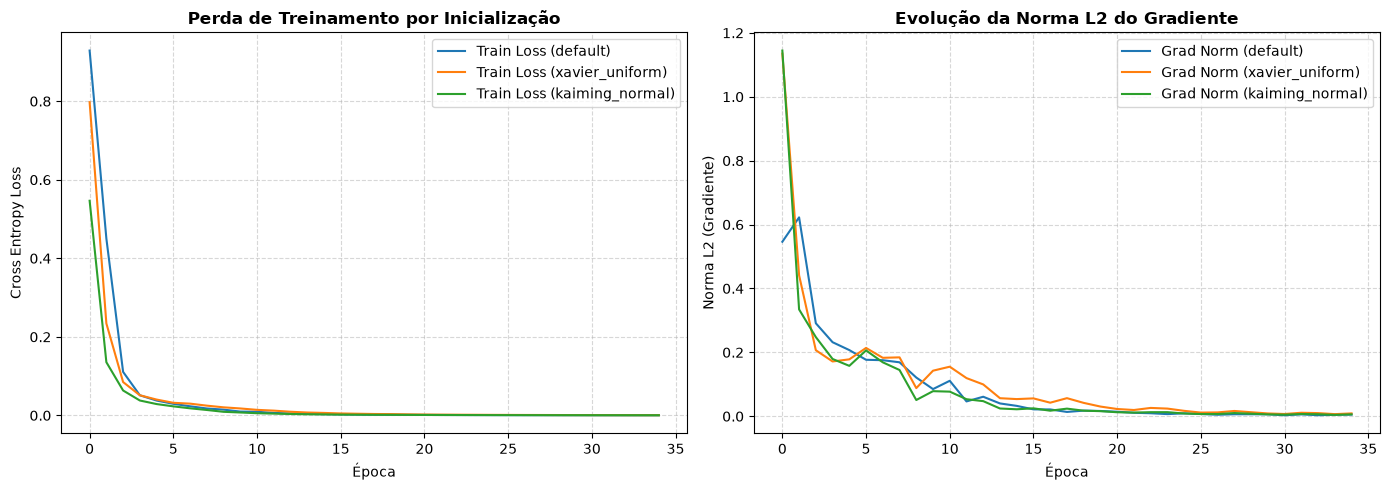

In [12]:
inits = ['default', 'xavier_uniform', 'kaiming_normal']
histories_init = {}

for init_name in inits:
    set_seed(42)
    model = EcommerceMLP(input_dim=X_train.shape[1], hidden_dims=[64, 32], output_dim=3)
    initialize_weights(model, init_name)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    
    history = train_stable(
        model, train_loader, val_loader, criterion, optimizer, 
        epochs=35, save_path=f"model_init_{init_name}.pt"
    )
    histories_init[init_name] = history

# Plotagem dos Diagnósticos do Experimento 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for init_name, hist in histories_init.items():
    axes[0].plot(hist['train_loss'], label=f"Train Loss ({init_name})")
    axes[1].plot(hist['grad_norms'], label=f"Grad Norm ({init_name})")

axes[0].set_title("Perda de Treinamento por Inicialização", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Cross Entropy Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Evolução da Norma L2 do Gradiente", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Norma L2 (Gradiente)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 🧪 Experimento 2: Impacto da Normalização (BatchNorm vs LayerNorm) e Regularização (Dropout)

Testaremos 4 configurações para verificar qual arquitetura entrega a maior acurácia de validação e previne *overfitting*:
1. **Sem Normalização** (`norm_type=None`, `dropout=0.0`)
2. **Com BatchNorm1d** (`norm_type='batchnorm'`, `dropout=0.0`)
3. **Com LayerNorm** (`norm_type='layernorm'`, `dropout=0.0`)
4. **BatchNorm1d + Dropout 0.2** (`norm_type='batchnorm'`, `dropout=0.2`)

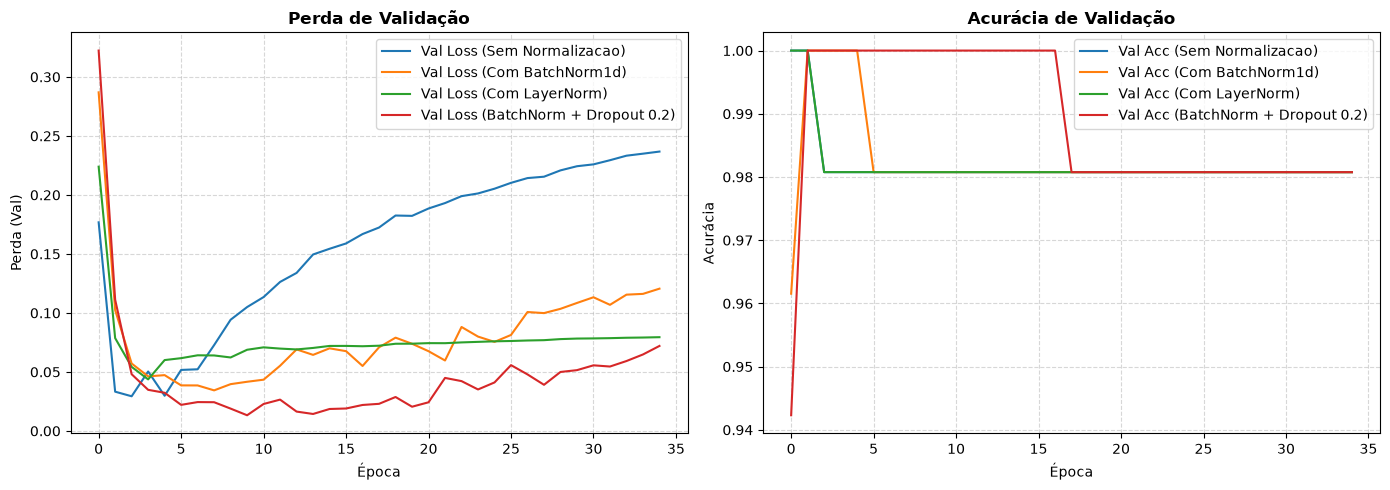

In [13]:
configs = {
    'Sem Normalizacao': {'norm_type': None, 'dropout': 0.0},
    'Com BatchNorm1d': {'norm_type': 'batchnorm', 'dropout': 0.0},
    'Com LayerNorm': {'norm_type': 'layernorm', 'dropout': 0.0},
    'BatchNorm + Dropout 0.2': {'norm_type': 'batchnorm', 'dropout': 0.2}
}

histories_norm = {}

for name, cfg in configs.items():
    set_seed(42)
    model = EcommerceMLP(
        input_dim=X_train.shape[1], hidden_dims=[64, 32], output_dim=3,
        norm_type=cfg['norm_type'], dropout_rate=cfg['dropout']
    )
    initialize_weights(model, 'kaiming_normal')
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    
    history = train_stable(
        model, train_loader, val_loader, criterion, optimizer, 
        epochs=35, save_path=f"model_{name.replace(' ', '_')}.pt"
    )
    histories_norm[name] = history

# Plotagem do Comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in histories_norm.items():
    axes[0].plot(hist['val_loss'], label=f"Val Loss ({name})")
    axes[1].plot(hist['val_acc'], label=f"Val Acc ({name})")

axes[0].set_title("Perda de Validação", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Perda (Val)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Acurácia de Validação", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 12. Avaliação Final no Conjunto de Teste

Carregaremos os pesos salvos do melhor modelo (salvo em `model_Com_BatchNorm1d.pt` ou similar) e realizaremos a avaliação cega no conjunto de **Teste**.

🎯 Acurácia no Conjunto de Teste: 96.23%
📊 F1-Score Ponderado no Teste: 0.9623

📋 Relatório de Classificação Completo:
              precision    recall  f1-score   support

     Neutral       0.89      1.00      0.94        16
   Satisfied       1.00      0.89      0.94        19
 Unsatisfied       1.00      1.00      1.00        18

    accuracy                           0.96        53
   macro avg       0.96      0.96      0.96        53
weighted avg       0.97      0.96      0.96        53



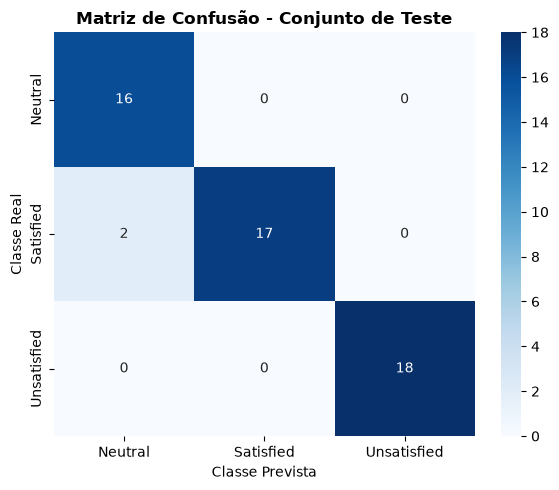

In [14]:
best_model = EcommerceMLP(
    input_dim=X_train.shape[1], hidden_dims=[64, 32], output_dim=3,
    norm_type='batchnorm', dropout_rate=0.0
)
best_model.load_state_dict(torch.load("model_Com_BatchNorm1d.pt"))
best_model.to(device)
best_model.eval()

y_preds, y_trues = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = best_model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        
        y_preds.extend(preds)
        y_trues.extend(y_batch.numpy())

# Métricas de Desempenho
acc_test = accuracy_score(y_trues, y_preds)
f1_test = f1_score(y_trues, y_preds, average='weighted')

print(f"🎯 Acurácia no Conjunto de Teste: {acc_test * 100:.2f}%")
print(f"📊 F1-Score Ponderado no Teste: {f1_test:.4f}\n")

target_names = label_encoder.classes_
print("📋 Relatório de Classificação Completo:")
print(classification_report(y_trues, y_preds, target_names=target_names))

# Matriz de Confusão
cm = confusion_matrix(y_trues, y_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Matriz de Confusão - Conjunto de Teste", fontsize=12, fontweight='bold')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()

## 13. Conclusão e Resumo dos Conceitos Práticos

Nesta primeira parte da Aula 04, consolidamos os seguintes conceitos fundamentais:
- **Preprocessamento Tabular Granular**: Como inspecionar, tratar e transformar atributos numéricos e categóricos sem provocar vazamento de dados (*data leakage*).
- **Inspeção de Dados em Cada Estágio**: Observamos a transição dos dados desde o CSV inicial até tensores PyTorch formatados.
- **Diagnóstico com Normas de Gradiente**: O monitoramento de $\|\nabla_{\theta} L\|_2$ indica a estabilidade do fluxo de gradientes durante a retropropagação.
- **Técnicas de Estabilização**: `BatchNorm1d` e inicializações adequadas (`Kaiming Normal`) reduzem a sensibilidade a hiperparâmetros e aceleram a convergência.

Na próxima parte, focaremos no problema de **Regressão** e na automação da busca por hiperparâmetros usando **Optuna**!